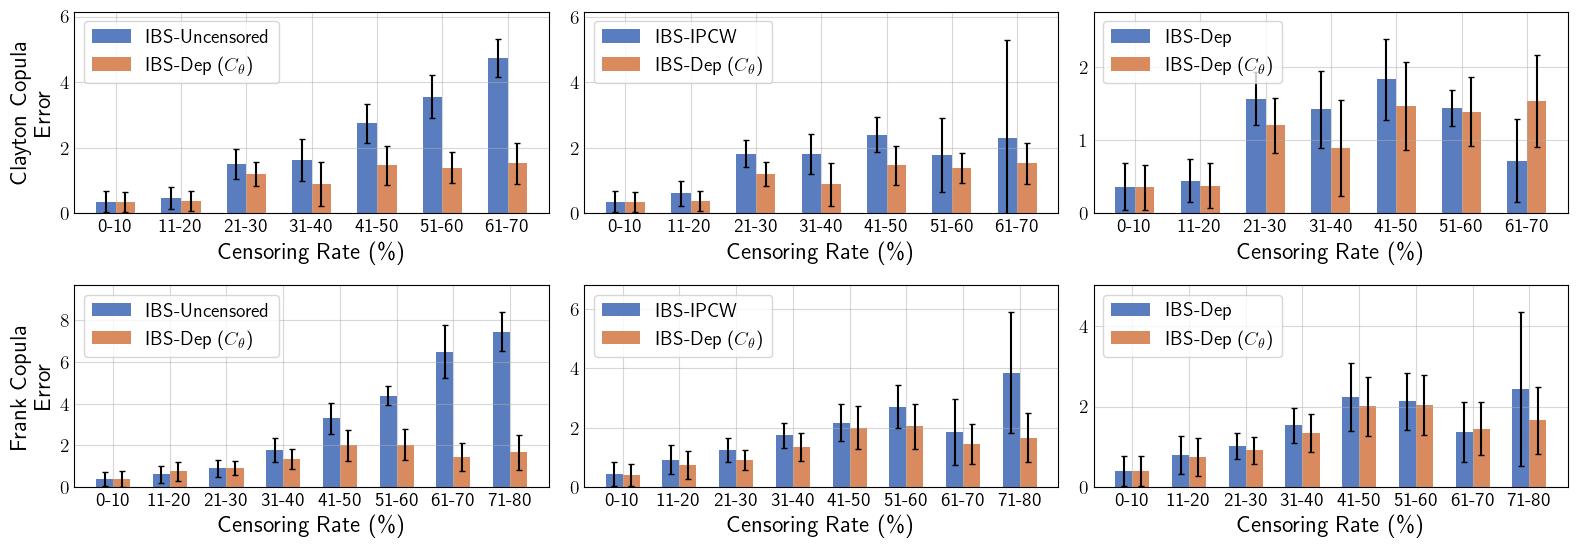

In [6]:
import numpy as np
import pandas as pd
import config as cfg
import seaborn as sns
from scipy.stats import zscore, sem, t
from matplotlib import pyplot as plt

plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 14.0,
    "legend.fontsize": "medium",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}"
})

filename = f"{cfg.RESULTS_DIR}/synthetic_results_censoring.csv"
df = pd.read_csv(filename)

# Define sigma-level (1-sigma/2-sigma)
sigma_level = 1

# Define a threshold for z-scores
z_threshold = 2

# Apply z-score filtering to numeric columns
columns = ['ibs_uncens_error', 'ibs_ipcw_error', 'ibs_indep_bg_error',
           'ibs_dep_bg_error', 'ibs_indep_bguw_error', 'ibs_dep_bguw_error']
df = df[(zscore(df[columns]) < z_threshold).all(axis=1)]

# Multiply all error columns by 100 to express as percentages
df[columns] = df[columns] * 100

# Define error columns
error_columns = [
    ("ibs_uncens_error", "ibs_dep_bg_error", "IBS-Uncensored", r"IBS-Dep ($C_{\theta}$)"),
    ("ibs_ipcw_error", "ibs_dep_bg_error", "IBS-IPCW", r"IBS-Dep ($C_{\theta}$)"),
    ("ibs_indep_bg_error", "ibs_dep_bg_error", r"IBS-Dep", r"IBS-Dep ($C_{\theta}$)")
]

# Convert censoring_rate to percentage for binning
df["censoring_pct"] = df["censoring_rate"] * 100

# Define bins and labels
bins = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
labels = ["0-10", "11-20", "21-30", "31-40", "41-50", "51-60", "61-70", "71-80"]
df['censoring_bin'] = pd.cut(df['censoring_rate'], bins=bins, labels=labels, include_lowest=True)

# Create subplots: 2 rows (Clayton, Frank) × 3 metrics
fig, axes = plt.subplots(2, 3, figsize=(16, 6))
axes = np.array(axes)

copulas = ["clayton", "frank"]

for row_idx, copula in enumerate(copulas):
    df_copula = df[df["copula_name"] == copula]

    for i, (metric1, metric2, label1, label2) in enumerate(error_columns):
        ax = axes[row_idx, i]
        grouped = df_copula.groupby("censoring_bin")[[metric1, metric2]].agg(['mean', 'std'])
        grouped.columns = ['_'.join(col) for col in grouped.columns]
        grouped = grouped.reset_index()

        # Drop bins where both metrics are NaN
        grouped = grouped.dropna(subset=[f"{metric1}_mean", f"{metric2}_mean", f"{metric1}_std", f"{metric2}_std"])

        plot_df = pd.DataFrame({
            "censoring_bin": pd.concat([grouped["censoring_bin"], grouped["censoring_bin"]]),
            "Metric": [metric1]*len(grouped) + [metric2]*len(grouped),
            "Mean": pd.concat([grouped[f"{metric1}_mean"], grouped[f"{metric2}_mean"]]),
            "Std": pd.concat([grouped[f"{metric1}_std"], grouped[f"{metric2}_std"]])
        }).dropna()

        # Plot bars
        sns.barplot(
            data=plot_df,
            x="censoring_bin", y="Mean", hue="Metric",
            ax=ax,
            capsize=0.1,
            errorbar=None,
            palette="muted",
            alpha=1,
            linewidth=3,
            width=0.6
        )

        # Add error bars manually
        hue_order = [metric1, metric2]
        for metric_idx, metric in enumerate(hue_order):
            bars = [bar for j, bar in enumerate(ax.containers[metric_idx])]
            std_vals = plot_df[plot_df['Metric'] == metric]["Std"].values
            for bar, err in zip(bars, std_vals):
                x = bar.get_x() + bar.get_width() / 2
                y = bar.get_height()
                ax.errorbar(x, y, yerr=sigma_level*err, fmt='none', c='black', capsize=2)

        # Replace legend
        ax.legend_.remove()
        ax.legend(
            handles=ax.containers[:2],
            labels=[label1, label2],
            fontsize=14
        )

        # Set axes labels and titles
        if i == 0:
            ax.set_ylabel(f"{copula.capitalize()} Copula\nError")
        else:
            ax.set_ylabel("")
        ax.set_xlabel("Censoring Rate (\%)")

        # Formatting
        y_min, y_max = ax.get_ylim()
        ax.set_ylim(0, y_max * 1.1)
        ax.grid(True, alpha=0.5)
        ax.tick_params(axis='y', which='both', length=0)
        ax.tick_params(axis='x', which='both', length=0)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f"{cfg.PLOTS_DIR}/synthetic_censoring.pdf", format='pdf', bbox_inches='tight')
plt.show()